# Auto-encoders with Keras

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy
import scipy.interpolate
import tensorflow as tf
import tensorflow.keras as keras

## Data loading

We will use MNIST data normalized to values in $[0, 1]$ (instead of $[0, 255]$). Note that usually we prefer normalizing by centering and diving by the standard deviation, but this one makes visualization easier.

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
nb_classes = 10
input_dim = 28 * 28
X_train = X_train.reshape(-1, input_dim).astype('float32')
X_test = X_test.reshape(-1, input_dim).astype('float32')

# 0 pixels stay at 0.
X_train = X_train / 255.0
X_test = X_test / 255.0

In [3]:
X_train.shape

(60000, 784)

## Simple auto-encoders

### Auto-encoder creation

Let's design a simple auto-encoder…

In [4]:
encoding_dim = 4
model = keras.models.Sequential()
model.add(keras.Input(shape=(input_dim,)))
model.add(keras.layers.Dense(encoding_dim, activation="leaky_relu"))
model.add(keras.layers.Dense(input_dim, activation="sigmoid"))
model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │         3,920 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,060 (27.58 KB)

 Trainable params: 7,060 (27.58 KB)

 Non-trainable params: 0 (0.00 B)

… and train it

In [5]:
model.fit(X_train, X_train,
          epochs=50,
          batch_size=256,
          validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1085 - val_loss: 0.0711
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0693 - val_loss: 0.0655
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0612 - val_loss: 0.0566
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0549 - val_loss: 0.0532
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0528 - val_loss: 0.0520
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0517 - val_loss: 0.0512
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0510 - val_loss: 0.0506
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0504 - val_loss: 0.0500
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0499 - val_loss: 0.0496
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0495 - val_loss: 0.0492
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0491 - val_loss: 0.0489
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

Onto a more complex one now.

In [6]:
encoder = keras.Sequential(
    [keras.layers.Input(shape=(input_dim,)),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(50,  activation="leaky_relu"),
     keras.layers.Dense(encoding_dim, activation="leaky_relu")],
    name="encoder")

decoder = keras.Sequential(
    [keras.layers.Input(shape=(encoding_dim,)),
     keras.layers.Dense(50,  activation="leaky_relu"),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(input_dim,
                        activation="sigmoid",
                        kernel_initializer="orthogonal")],
    name="decoder")

autoencoder = keras.Sequential(
    [keras.layers.Input(shape=(input_dim,)), encoder, decoder],
    name="autoencoder")
autoencoder.compile(optimizer="adam", loss="mean_squared_error")


encoder.summary()
decoder.summary()
autoencoder.summary()



Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 150)            │       117,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         7,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,154 (578.73 KB)

 Trainable params: 148,154 (578.73 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 4)              │       148,154 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 784)            │       148,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297,088 (1.13 MB)

 Trainable params: 297,088 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
encoding_dim = 4

In [8]:
autoencoder.fit(X_train, X_train,
          epochs=50,
          batch_size=256,
          validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0747 - val_loss: 0.0565
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0507 - val_loss: 0.0443
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0417 - val_loss: 0.0394
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0382 - val_loss: 0.0369
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0362 - val_loss: 0.0355
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0348 - val_loss: 0.0342
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0337 - val_loss: 0.0333
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0326 - val_loss: 0.0323
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0317 - val_loss: 0.0315
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0311 - val_loss: 0.0310
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0306 - val_loss: 0.0304
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

### Prediction on white noise

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step


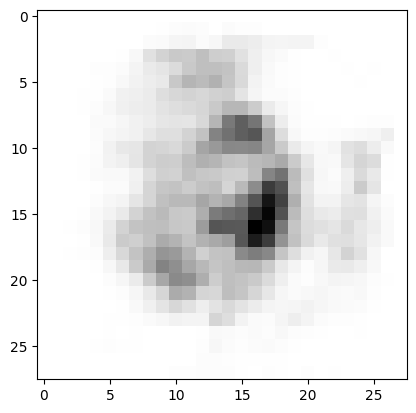

In [9]:
white_noise = numpy.random.random_sample((1, encoding_dim))
plt.imshow(decoder.predict(white_noise).reshape(28, 28), cmap="gray_r")
plt.show()

### Encoding test data

Let's encode unseen data into the code computed by the encoder

In [10]:
codes = encoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [11]:
codes.shape

(10000, 4)

### Computation of centroids in the code space for each digit

In [12]:
means = numpy.vstack([codes[y_test == i].mean(axis=0)
                      for i in range(nb_classes)])
stds = numpy.vstack([codes[y_test == i].std(axis=0)
                     for i in range(nb_classes)])

for i in range(10):
  dimension_stats = [f"{mean:5.2f}±{std:.2f}"
                     for mean, std in zip(means[i], stds[i])]
  print(f"Digit {i} {', '.join(dimension_stats)}")

Digit 0  8.59±3.70, -4.10±1.87, -1.82±3.37, 10.22±4.56
Digit 1  7.14±3.52, 25.09±4.83, -0.12±1.42,  5.54±4.52
Digit 2 -1.56±2.46,  6.05±5.02, -3.74±2.53,  4.99±4.39
Digit 3  2.66±2.23,  0.47±2.67, -5.83±2.62,  1.06±3.14
Digit 4 14.89±3.84,  8.26±3.60,  4.33±3.28,  5.20±5.36
Digit 5  8.85±3.08,  2.66±3.83, -5.60±2.35,  5.09±4.73
Digit 6 19.22±5.51,  0.16±2.81, -1.37±3.06,  7.71±4.50
Digit 7  8.88±3.97, 15.00±4.68, 10.85±4.78,  6.33±5.59
Digit 8  7.87±3.10,  9.30±5.03, -6.02±2.41,  4.12±4.56
Digit 9 16.08±4.28, 11.36±4.73,  4.52±3.38,  4.91±5.19


Decoding of the centroids by the decoder:

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step


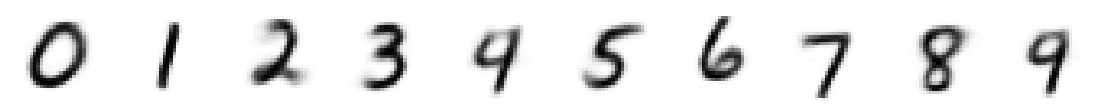

In [13]:
f, ax = plt.subplots(1, nb_classes, figsize=(1.4 * nb_classes, 2))

centroid_images = decoder.predict(means).reshape(-1, 28, 28)

for i, centroid_image in enumerate(centroid_images):
  ax[i].imshow(centroid_image, cmap="gray_r")
  ax[i].axis("off")
plt.show()

### Latent walk between two digit centroids

Now that we know where are the centroids for each digit, we can go through the latent space in-between two of them.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step


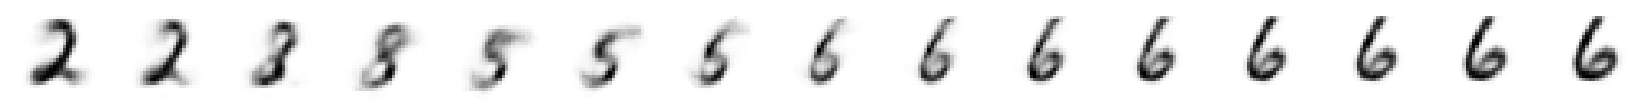

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


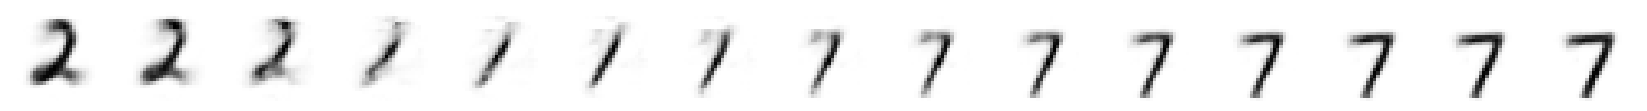

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


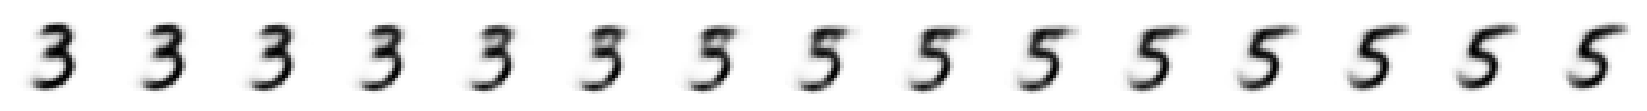

In [14]:
def latent_walk(start: int, end: int, n: int = 15):
  interpolator = scipy.interpolate.interp1d([0, n - 1],
                                            means[[start, end], :],
                                            axis=0)
  interpolated_codes = interpolator(range(n))
  interpolated_images = decoder.predict(interpolated_codes).reshape(-1, 28, 28)

  f, ax = plt.subplots(1, n, figsize=(n * 1.4, 2))
  for i, interpolated_image in enumerate(interpolated_images):
    ax[i].imshow(interpolated_image, cmap="gray_r")
    ax[i].axis("off")
  plt.show()


latent_walk(2, 6)
latent_walk(2, 7)
latent_walk(3, 5)

### Auto-encoding of the complete test base

In [15]:
decoded_imgs = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [16]:
decoded_imgs_train = model.predict(X_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


### Visualization

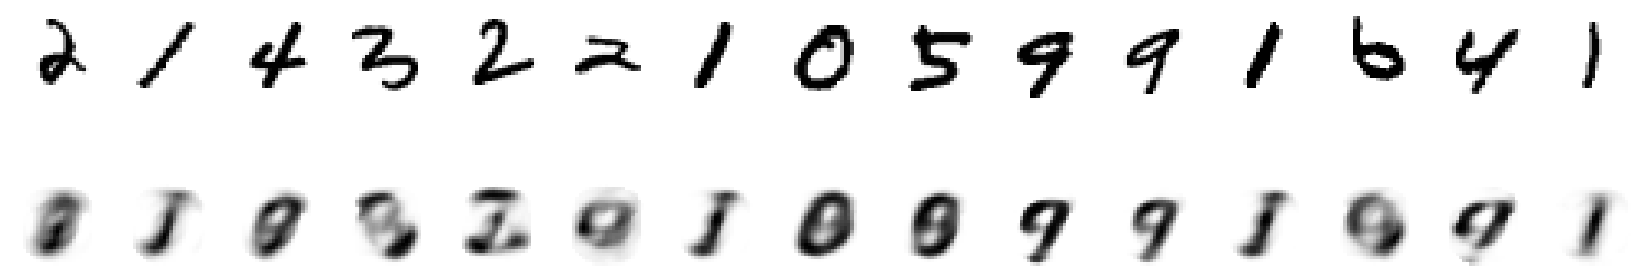

In [17]:
n = 15  # Number of digits to display

random_indexes = numpy.random.choice(decoded_imgs.shape[0],
                                     size=n,
                                     replace=False)

f, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, random_index in enumerate(random_indexes):
    # Original input is on the top row
    ax[0, i].imshow(X_test[random_index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # Reconstruction is on the bottom row
    ax[1, i].imshow(decoded_imgs[random_index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

Worst reconstructions on train


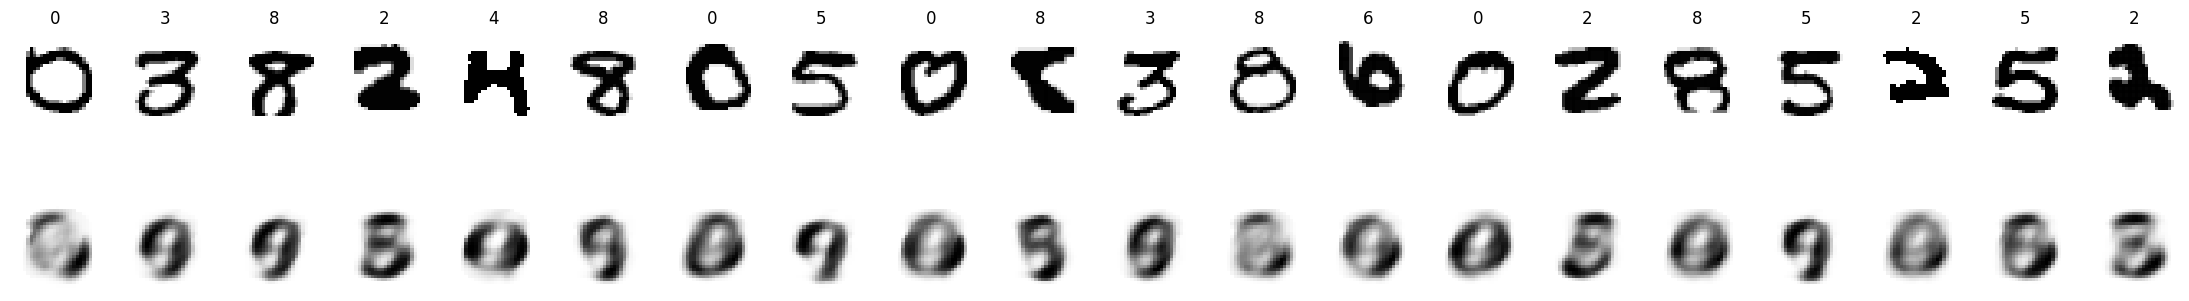

Worst reconstructions on test


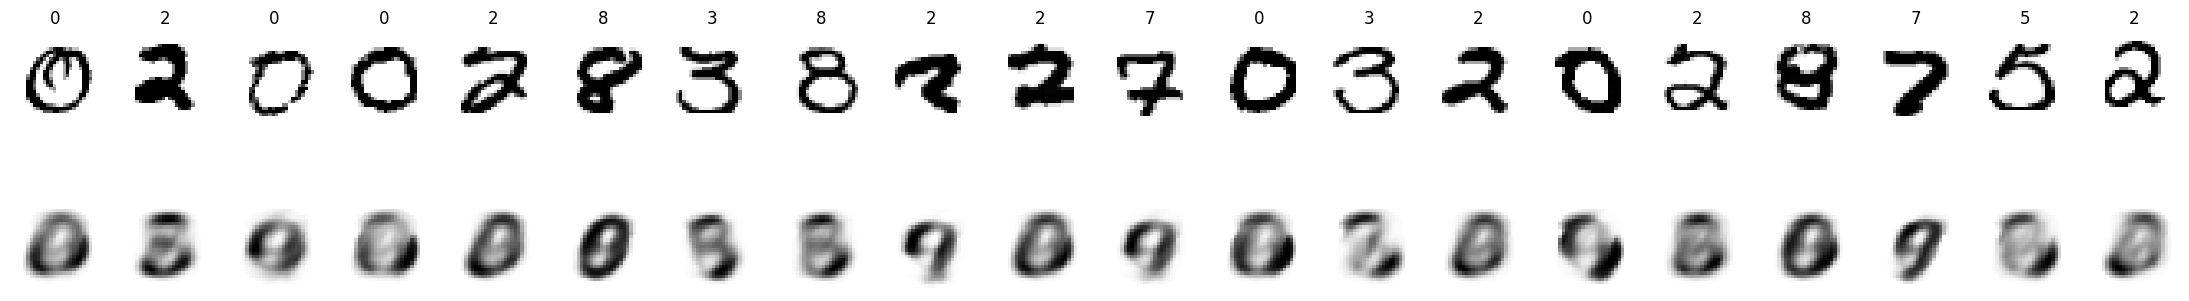

Best reconstructions on train


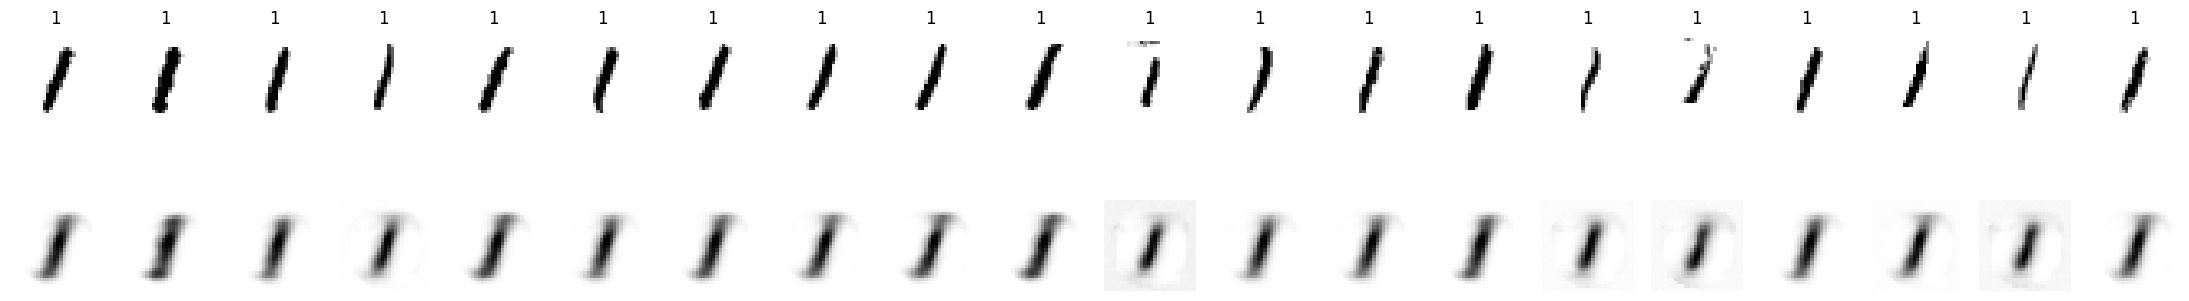

Best reconstructions on test


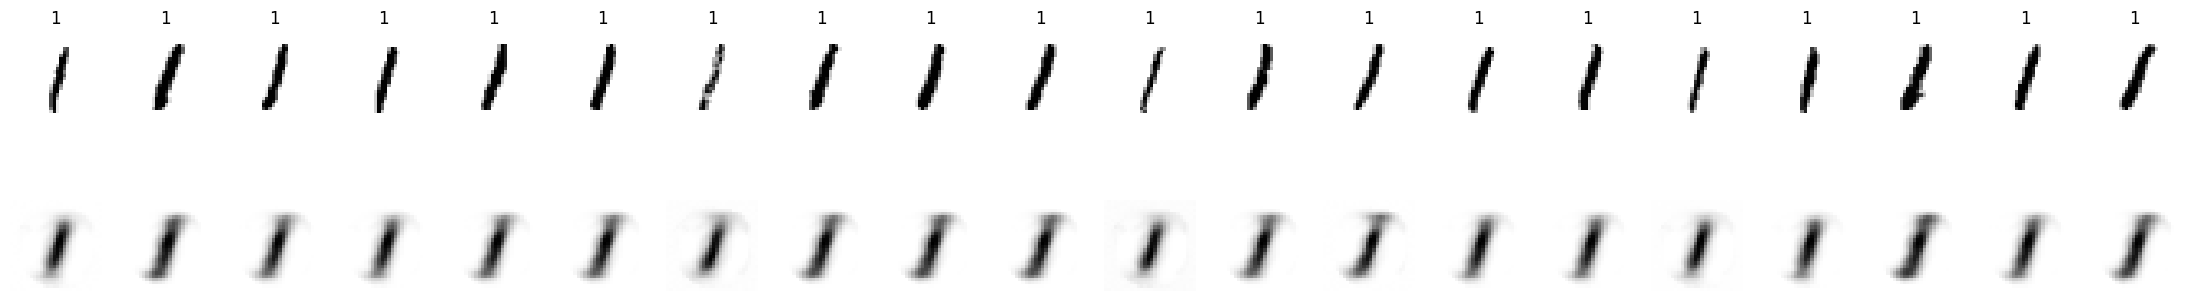

In [18]:
mse = keras.losses.MeanSquaredError(reduction="none")
test_anomalies = (-mse(decoded_imgs, X_test).numpy()).argsort()
train_anomalies = (-mse(decoded_imgs_train, X_train).numpy()).argsort()

n = 20

print("Worst reconstructions on train")
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, index in enumerate(train_anomalies[:n]):
    # Original input is on the top row
    ax[0, i].set_title(y_train[index])
    ax[0, i].imshow(X_train[index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # Reconstruction is on the bottom row
    ax[1, i].imshow(decoded_imgs_train[index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()


print("Worst reconstructions on test")
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, index in enumerate(test_anomalies[:n]):
    # Original input is on the top row
    ax[0, i].set_title(y_test[index])
    ax[0, i].imshow(X_test[index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # Reconstruction is on the bottom row
    ax[1, i].imshow(decoded_imgs[index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

print("Best reconstructions on train")
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, index in enumerate(train_anomalies[-n:]):
    # Original input is on the top row
    ax[0, i].set_title(y_train[index])
    ax[0, i].imshow(X_train[index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # Reconstruction is on the bottom row
    ax[1, i].imshow(decoded_imgs_train[index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()


print("Best reconstructions on test")
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, index in enumerate(test_anomalies[-n:]):
    # Original input is on the top row
    ax[0, i].set_title(y_test[index])
    ax[0, i].imshow(X_test[index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # Reconstruction is on the bottom row
    ax[1, i].imshow(decoded_imgs[index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

## Denoising auto-encoders

### Gaussian noise application

In [19]:
noise_factor = 0.5
X_train_noisy = X_train + numpy.random.normal(0, noise_factor, X_train.shape)
X_test_noisy = X_test + numpy.random.normal(0, noise_factor, X_test.shape)

# Clipping to avoid values above 1 or below 0
numpy.clip(X_train_noisy, 0, 1, out=X_train_noisy)
numpy.clip(X_test_noisy, 0, 1, out=X_test_noisy)

array([[0.1337802 , 0.        , 0.        , ..., 0.80824334, 0.        ,
        0.00938504],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.65226782],
       [0.        , 0.37111744, 0.        , ..., 0.09395888, 0.14051365,
        0.31390973],
       ...,
       [0.        , 0.43233806, 0.        , ..., 0.        , 0.64010814,
        0.        ],
       [0.        , 0.06002196, 0.        , ..., 0.4793572 , 0.0611599 ,
        0.06742616],
       [0.3034324 , 0.402117  , 0.        , ..., 0.        , 0.25202092,
        0.        ]])

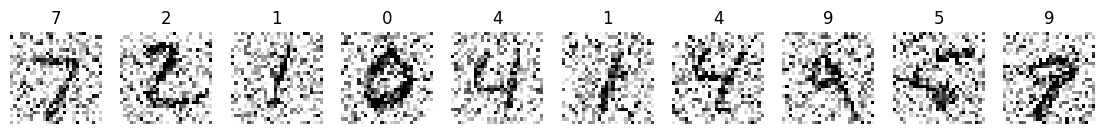

In [20]:
n = 10
f, ax = plt.subplots(1, n, figsize=(n * 1.4, 2))
for i in range(n):
    ax[i].imshow(X_test_noisy[i].reshape(28, 28), cmap="gray_r")
    ax[i].set_title(y_test[i])
    ax[i].axis("off")
plt.show()

### Denoising auto-encoder creation


In [21]:
encoding_dim = 4
model = keras.models.Sequential()
model.add(keras.layers.Input(shape=(input_dim,)))
model.add(keras.layers.Dense(encoding_dim, activation="relu"))
model.add(keras.layers.Dense(input_dim, activation="sigmoid"))
model.compile(optimizer="adam", loss="mean_squared_error")

### Training

In [22]:
model.fit(X_train_noisy, X_train,
          epochs=50,
          batch_size=256,
          validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0965 - val_loss: 0.0680
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0680 - val_loss: 0.0667
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0648 - val_loss: 0.0618
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0605 - val_loss: 0.0588
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0578 - val_loss: 0.0563
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0555 - val_loss: 0.0542
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0541 - val_loss: 0.0532
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0533 - val_loss: 0.0525
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0527 - val_loss: 0.0521
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0523 - val_loss: 0.0517
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0520 - val_loss: 0.0513
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

### Auto-encoding the complete test base

Auto-encode the test images and store the resulting images in the `decoded_imgs` variable

In [23]:
decoded_imgs = model.predict(X_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


### Visualization

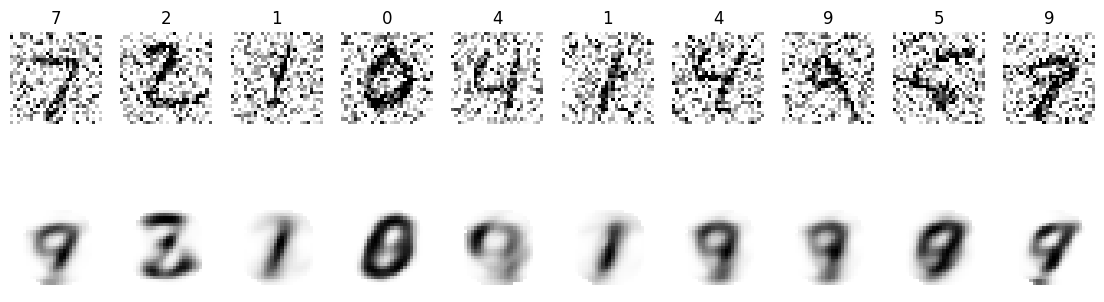

In [24]:
n = 10
f, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i in range(n):
    # Original input is on the top row
    ax[0, i].imshow(X_test_noisy[i].reshape(28, 28), cmap="gray_r")
    ax[0, i].set_title(str(y_test[i]))
    ax[0, i].axis("off")

    # Reconstruction is on the bottom row
    ax[1, i].imshow(decoded_imgs[i].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

### Denoising convolutional auto-encoders

We first need to reshape to $(\text{batch} \times \text{width} \times \text{height} \times \text{channels})$ to use Keras.

In [25]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
X_train_noisy = X_train_noisy.reshape(-1, 28, 28, 1)
X_test_noisy = X_test_noisy.reshape(-1, 28, 28, 1)

### Denoising convolutional auto-encoder creation

In [26]:
encoding_dim = 4

model = keras.models.Sequential()
# Encoding
model.add(keras.Input(shape=X_train.shape[1:]))
model.add(keras.layers.Conv2D(32, (3, 3), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2D(32, (2, 2), (2, 2), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2D(32, (3, 3), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2D(32, (2, 2), (2, 2), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2D(1, (3, 3), activation="leaky_relu", padding="same"))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(encoding_dim))

# Decoding
model.add(keras.layers.Dense(49))
model.add(keras.layers.Reshape((7, 7, 1)))
model.add(keras.layers.Conv2D(32, (3, 3), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2DTranspose(32, (2, 2), (2, 2), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2D(32, (3, 3), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2DTranspose(32, (2, 2), (2, 2), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same"))

model.compile(optimizer=keras.optimizers.Adam(0.0001), loss="mean_squared_error")

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 32)       │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 1)        │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 49)             │           245 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 32)     │         4,128 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         4,128 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,671 (143.25 KB)

 Trainable params: 36,671 (143.25 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [27]:
model.fit(X_train_noisy, X_train,
          epochs=100,
          batch_size=128,
          validation_split=0.2)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.1209 - val_loss: 0.0683
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0657 - val_loss: 0.0618
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0594 - val_loss: 0.0571
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0557 - val_loss: 0.0543
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0534 - val_loss: 0.0527
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0521 - val_loss: 0.0517
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0512 - val_loss: 0.0509
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0505 - val_loss: 0.0503
Epoch 9/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0500 - val_loss: 0.0497
Epoch 10/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0495 - val_loss: 0.0493
Epoch 11/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0490 - val_loss: 0.0490
Epoch 12/100
375/375 ━━━━━━━━━━

### Visualization

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


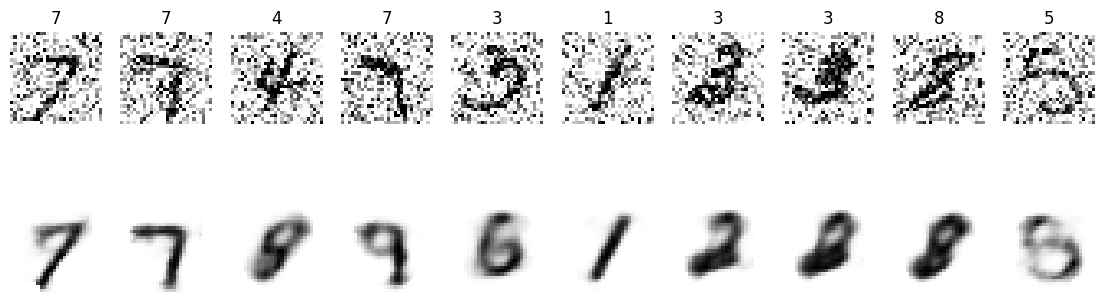

In [28]:
decoded_imgs = model.predict(X_test_noisy).reshape(-1, 28, 28)

n = 10
f, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))

random_indexes = numpy.random.choice(X_test.shape[0],
                                     replace=False,
                                     size=n)

for i, random_index in enumerate(random_indexes):
    # Original on the top row
    ax[0, i].set_title(str(y_test[random_index]))
    ax[0, i].imshow(X_test_noisy[random_index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # Reconstruction on the bottom row
    ax[1, i].imshow(decoded_imgs[random_index], cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

### Visualization on images on which we didn't add noise

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


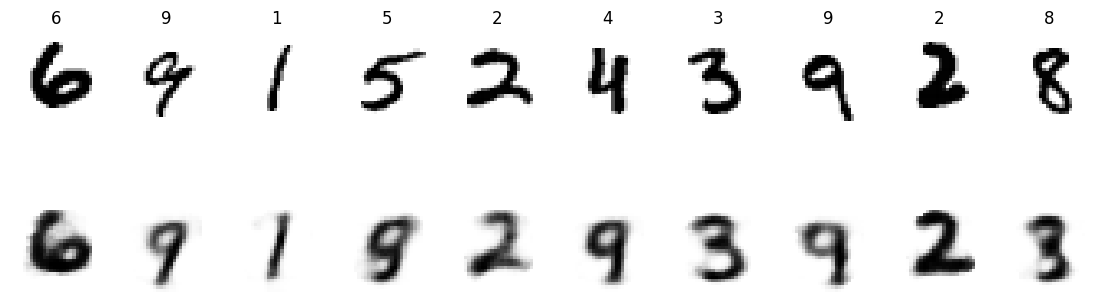

In [29]:
decoded_imgs = model.predict(X_test).reshape(-1, 28, 28)

n = 10
f, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))

random_indexes = numpy.random.choice(X_test.shape[0],
                                     replace=False,
                                     size=n)

for i, random_index in enumerate(random_indexes):
    # Original on the top row
    ax[0, i].set_title(str(y_test[random_index]))
    ax[0, i].imshow(X_test[random_index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # Reconstruction on the bottom row
    ax[1, i].imshow(decoded_imgs[random_index], cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

## Variational auto-encoders

For VAEs, the training method is less straightforward (due to the need for the [reparametrization trick](https://stats.stackexchange.com/questions/199605/how-does-the-reparameterization-trick-for-vaes-work-and-why-is-it-important)). The suggestion by the Keras maintainers is to use the following code:

In [30]:
class Sampling(keras.layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [31]:
latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = keras.layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = keras.layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(16, activation="relu")(x)
z_mean = keras.layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = keras.layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 16)        │     50,192 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = keras.layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = keras.layers.Reshape((7, 7, 64))(x)
x = keras.layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = keras.layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = keras.layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [34]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
vae.fit(X_train, epochs=30, batch_size=128)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - kl_loss: 1.7101 - loss: 212.9863 - reconstruction_loss: 211.2764
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - kl_loss: 4.7365 - loss: 168.3324 - reconstruction_loss: 163.5959
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 5.1515 - loss: 162.0545 - reconstruction_loss: 156.9030
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.4131 - loss: 159.1678 - reconstruction_loss: 153.7547
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - kl_loss: 5.5510 - loss: 157.4014 - reconstruction_loss: 151.8504
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.6492 - loss: 156.2999 - reconstruction_loss: 150.6507
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 5.7218 - loss: 155.3643 - reconstruction_loss: 149.6426
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 5.8028 - loss: 154.6326 - reconstruction_loss: 148.8297
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8m

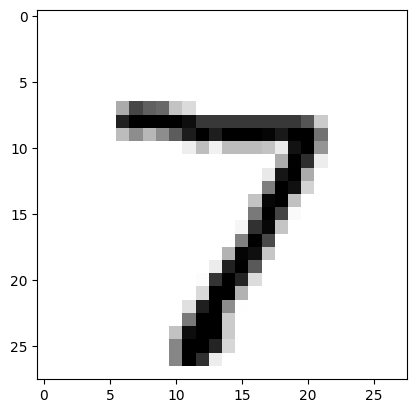

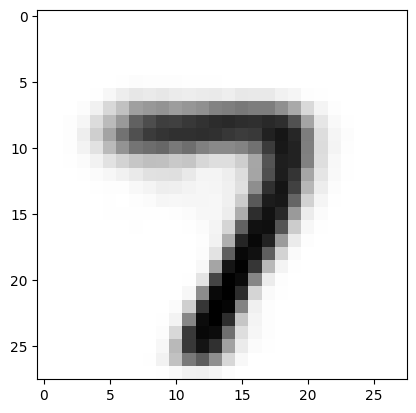

In [35]:
def auto_encode_example(example: numpy.ndarray) -> None:
  x_z_mean, x_z_log_var, x_z = vae.encoder(example[None, ...])
  decoded = vae.decoder(x_z).numpy().squeeze()
  plt.imshow(example.squeeze(), cmap="gray_r")
  plt.show()
  plt.imshow(decoded, cmap="gray_r")
  plt.show()


auto_encode_example(X_test[0])